# M-function scaling beyond variational Sinkhorn

This notebook generates `fig:sinkhorn-mfunctions-nonvariational-scaling`.
It illustrates the lossy, non-variational scaling system
\[
    \sigma_i r_i + \sum_j r_i K_{ij}s_j = a_i,
    \qquad
    \tau_j s_j + \sum_i \eta_{ij} r_i K_{ij}s_j = b_j,
\]
with Sinkhorn-like updates
\[
    r_i^+ = \frac{a_i}{\sigma_i+\sum_j K_{ij}s_j},
    \qquad
    s_j^+ = \frac{b_j}{\tau_j+\sum_i \eta_{ij}K_{ij}r_i}.
\]
The model is deliberately simple: losses \(\eta_{ij}\neq 1\) break the cross-partial symmetry of a variational formulation, while the fixed-point map keeps the monotone \(M\)-function structure discussed in the text.

The figure uses two two-dimensional Gaussian-mixture point clouds.  Across columns, the outside-option coefficients \(\sigma\) and \(\tau\) increase.  Colors encode centered log-scalings, while faint violet links show the largest entries of the induced lossy transport pattern.


In [1]:
from pathlib import Path
import os
import shutil
import sys

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mpl-ot4ml")

for candidate in [Path.cwd(), Path.cwd() / "notebooks-figures", Path.cwd().parent / "notebooks-figures"]:
    if (candidate / "figure_style.py").exists():
        sys.path.insert(0, str(candidate.resolve()))
        break
else:
    raise RuntimeError("Could not locate figure_style.py")

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap, Normalize, to_rgb

from figure_style import BLUE, GRAY, RED, VIOLET, ROOT, figure_dir, remove_axes, save_pdf, setup_matplotlib

setup_matplotlib()

NAME = "sinkhorn-mfunctions-nonvariational-scaling"
OUT = figure_dir(NAME)
THUMB = ROOT / "notebooks-figures" / "thumbnails" / f"{NAME}.png"
ARXIV = ROOT / "arxiv" / "figures"
ARXIV.mkdir(parents=True, exist_ok=True)


## Two Gaussian-mixture clouds

The same empirical source and target measures are used in both panels.  The source weights and target weights are uniform, while the geometry is encoded by the Gibbs kernel \(K_{ij}=\exp(-\|x_i-y_j\|^2/\varepsilon)\), normalized only to keep the scaling variables in a readable numerical range.

In [2]:
rng = np.random.default_rng(2048)


def sample_gaussian_mixture(n, weights, means, covs):
    weights = np.asarray(weights, dtype=float)
    weights = weights / weights.sum()
    counts = np.floor(n * weights).astype(int)
    while counts.sum() < n:
        counts[np.argmax(n * weights - counts)] += 1
    while counts.sum() > n:
        counts[np.argmax(counts - n * weights)] -= 1
    pts = []
    for count, mean, cov in zip(counts, means, covs):
        pts.append(rng.multivariate_normal(np.asarray(mean), np.asarray(cov), size=count))
    pts = np.vstack(pts)
    rng.shuffle(pts)
    return pts

n = 128
m = 128
x = sample_gaussian_mixture(
    n,
    weights=[0.58, 0.42],
    means=[[-1.18, -0.18], [0.05, 0.92]],
    covs=[[[0.13, 0.030], [0.030, 0.075]], [[0.095, -0.026], [-0.026, 0.145]]],
)
y = sample_gaussian_mixture(
    m,
    weights=[0.48, 0.52],
    means=[[-0.18, 1.10], [1.18, -0.40]],
    covs=[[[0.125, -0.030], [-0.030, 0.095]], [[0.165, 0.050], [0.050, 0.085]]],
)

a = np.full(n, 1.0 / n)
b = np.full(m, 1.0 / m)

C = np.sum((x[:, None, :] - y[None, :, :]) ** 2, axis=2)
epsilon_kernel = 0.68
K = np.exp(-C / epsilon_kernel)
K = K / K.sum(axis=1).mean()

# Losses are smaller on long links and asymmetric in the spatial example.
eta_uniform = 0.66 + 0.32 * np.exp(-C / np.median(C))
directional_bias = np.tanh(1.12 * (x[:, None, 0] + 0.55 * y[None, :, 0] - 0.35 * x[:, None, 1] + 0.72 * y[None, :, 1]))
eta_spatial = 0.54 + 0.29 * np.exp(-C / np.median(C)) + 0.17 * directional_bias
eta_spatial = np.clip(eta_spatial, 0.32, 0.985)

rho_values = np.array([0.0012, 0.0038, 0.012, 0.038])


## Lossy scaling fixed point

The update is the Gauss--Seidel version of the coordinate-clearing iteration.  The outside terms remove the additive gauge invariance of balanced Sinkhorn, so the scale of \(r\) and \(s\) is pinned by \(\sigma\) and \(\tau\).

In [3]:
def lossy_scaling(K, eta, a, b, sigma, tau, *, max_iter=20000, tol=3e-13):
    n, m = K.shape
    r = np.full(n, 1.0 / n)
    s = np.ones(m)
    for it in range(max_iter):
        r_new = a / (sigma + K @ s)
        s_new = b / (tau + (eta * K).T @ r_new)
        err = max(np.max(np.abs(r_new - r)), np.max(np.abs(s_new - s)))
        r, s = r_new, s_new
        if err < tol:
            return r, s, it + 1
    raise RuntimeError(f"lossy scaling did not converge; final update error={err:.2e}")


def display_log(z, weights):
    return np.log(np.maximum(z, 1e-300))

def family_uniform(rho):
    return np.full(n, rho), np.full(m, rho)


def family_spatial(rho):
    sx = (x[:, 0] - x[:, 0].min()) / (np.ptp(x[:, 0]) + 1e-12)
    ty = (y[:, 1] - y[:, 1].min()) / (np.ptp(y[:, 1]) + 1e-12)
    sigma = rho * (0.25 + 3.20 * sx**1.15)
    tau = 1.55 * rho * (0.25 + 3.10 * (1.0 - ty)**1.10)
    return sigma, tau

families = [
    ("uniform", eta_uniform, family_uniform),
    ("spatial", eta_spatial, family_spatial),
]

solutions = {}
for family_name, eta, sigma_tau in families:
    sols = []
    for rho in rho_values:
        sigma, tau = sigma_tau(float(rho))
        r, s, niter = lossy_scaling(K, eta, a, b, sigma, tau)
        row_res = np.max(np.abs(sigma * r + r * (K @ s) - a))
        col_res = np.max(np.abs(tau * s + s * ((eta * K).T @ r) - b))
        if max(row_res, col_res) > 2e-10:
            raise RuntimeError((family_name, rho, row_res, col_res))
        sols.append({"rho": float(rho), "sigma": sigma, "tau": tau, "r": r, "s": s, "niter": niter})
    solutions[family_name] = sols

for family_name, sols in solutions.items():
    print(family_name, [sol["niter"] for sol in sols])


uniform [149, 97, 61, 33]
spatial [144, 92, 51, 23]


## Exported panels

Each exported panel has two rows: centered source log-scalings \(\log r-\langle\log r\rangle\) and centered target log-scalings \(\log s-\langle\log s\rangle\).  The centering removes the uninteresting global scale and makes the spatial deformation caused by the outside terms visible.  Faint violet links mark the largest entries of the induced plan \(P_{ij}=r_iK_{ij}s_j\).


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


latex/figures/sinkhorn-mfunctions-nonvariational-scaling/uniform-outside.pdf


latex/figures/sinkhorn-mfunctions-nonvariational-scaling/spatial-outside.pdf


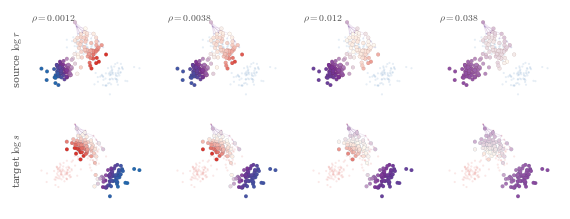

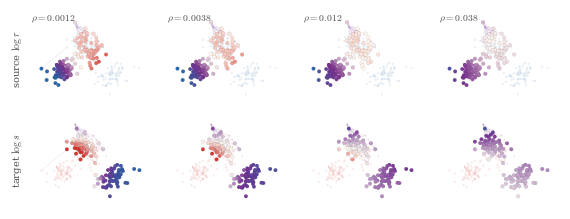

In [4]:
cmap_log = LinearSegmentedColormap.from_list("centered_log_scaling", [RED, "#fffaf0", VIOLET, BLUE])
source_edge = "#5b1a18"
target_edge = "#143052"
link_color = np.array(to_rgb(VIOLET))
all_points = np.vstack([x, y])
span = all_points.max(axis=0) - all_points.min(axis=0)
pad = 0.13 * max(span)
lims_x = (all_points[:, 0].min() - pad, all_points[:, 0].max() + pad)
lims_y = (all_points[:, 1].min() - pad, all_points[:, 1].max() + pad)


def centered_log(z, weights):
    values = np.log(np.maximum(z, 1e-300))
    return values - np.average(values, weights=weights)


def common_norm(values, q=98.5):
    radius = np.percentile(np.abs(np.concatenate(values)), q)
    radius = max(float(radius), 1e-9)
    return Normalize(-radius, radius)


def add_context(ax, active_row):
    ax.scatter(x[:, 0], x[:, 1], s=2.4, color=RED, alpha=0.11 if active_row == "target" else 0.0, edgecolor="none", zorder=1)
    ax.scatter(y[:, 0], y[:, 1], s=2.4, color=BLUE, alpha=0.11 if active_row == "source" else 0.0, edgecolor="none", zorder=1)


def add_strong_links(ax, sol, eta, n_links=34):
    P = sol["r"][:, None] * K * sol["s"][None, :]
    effective = eta * P
    flat = effective.ravel()
    n_links = min(n_links, flat.size)
    selected = np.argpartition(flat, -n_links)[-n_links:]
    selected = selected[np.argsort(flat[selected])]
    masses = flat[selected]
    masses = masses / max(float(masses.max()), 1e-15)
    segments, colors, widths = [], [], []
    for idx, mass in zip(selected, masses):
        i, j = np.unravel_index(int(idx), effective.shape)
        segments.append([x[i], y[j]])
        colors.append((*link_color, 0.07 + 0.20 * float(mass)))
        widths.append(0.16 + 0.55 * np.sqrt(float(mass)))
    ax.add_collection(LineCollection(segments, colors=colors, linewidths=widths, zorder=2, capstyle="round"))


def plot_family(family_name, filename):
    sols = solutions[family_name]
    eta = eta_uniform if family_name == "uniform" else eta_spatial
    U = [centered_log(sol["r"], a) for sol in sols]
    V = [centered_log(sol["s"], b) for sol in sols]
    norms = [common_norm(U), common_norm(V)]

    fig, axes = plt.subplots(2, len(sols), figsize=(5.80, 2.28), sharex=True, sharey=True)
    plt.subplots_adjust(wspace=0.018, hspace=0.045, left=0.062, right=0.996, top=0.91, bottom=0.035)

    for col, sol in enumerate(sols):
        for row, (pts, values, norm, edge_color, label, active_row) in enumerate(
            [
                (x, U[col], norms[0], source_edge, r"source $\log r$", "source"),
                (y, V[col], norms[1], target_edge, r"target $\log s$", "target"),
            ]
        ):
            ax = axes[row, col]
            add_strong_links(ax, sol, eta)
            add_context(ax, active_row)
            ax.scatter(
                pts[:, 0],
                pts[:, 1],
                c=values,
                cmap=cmap_log,
                norm=norm,
                s=7.2,
                marker="o",
                edgecolor=edge_color,
                linewidth=0.055,
                alpha=0.98,
                zorder=4,
            )
            ax.set_xlim(*lims_x)
            ax.set_ylim(*lims_y)
            ax.set_aspect("equal")
            remove_axes(ax)
            if row == 0:
                ax.text(
                    0.02,
                    0.965,
                    rf"$\rho={sol['rho']:.3g}$",
                    transform=ax.transAxes,
                    ha="left",
                    va="top",
                    fontsize=7.0,
                    color=GRAY,
                )
            if col == 0:
                ax.text(
                    -0.038,
                    0.50,
                    label,
                    transform=ax.transAxes,
                    rotation=90,
                    ha="right",
                    va="center",
                    fontsize=7.2,
                    color=GRAY,
                )
    pdf_path = OUT / filename
    save_pdf(fig, pdf_path, pad_inches=0.010)
    return fig, pdf_path

figs = []
for family_name, filename in [("uniform", "uniform-outside.pdf"), ("spatial", "spatial-outside.pdf")]:
    fig, pdf_path = plot_family(family_name, filename)
    figs.append(fig)
    shutil.copyfile(pdf_path, ARXIV / f"{NAME}--{pdf_path.stem}.pdf")
    print(pdf_path.relative_to(ROOT))


## Thumbnail

The thumbnail is a compact contact sheet used by the interactive book and the figure gallery.

notebooks-figures/thumbnails/sinkhorn-mfunctions-nonvariational-scaling.png


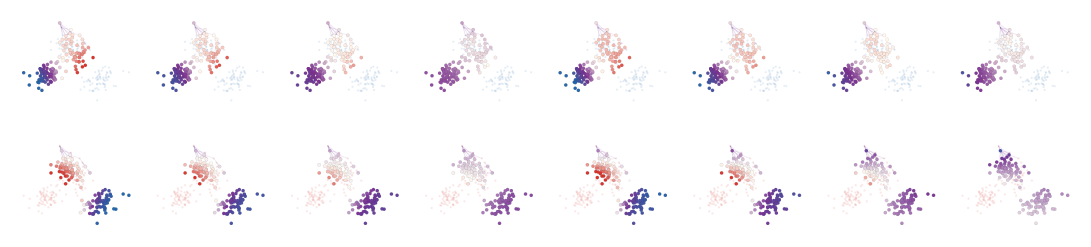

In [5]:
def draw_family_on_axes(axes, family_name):
    sols = solutions[family_name]
    eta = eta_uniform if family_name == "uniform" else eta_spatial
    U = [centered_log(sol["r"], a) for sol in sols]
    V = [centered_log(sol["s"], b) for sol in sols]
    norms = [common_norm(U), common_norm(V)]
    for col, sol in enumerate(sols):
        for row, (pts, values, norm, edge_color, active_row) in enumerate(
            [(x, U[col], norms[0], source_edge, "source"), (y, V[col], norms[1], target_edge, "target")]
        ):
            ax = axes[row, col]
            add_strong_links(ax, sol, eta, n_links=22)
            add_context(ax, active_row)
            ax.scatter(
                pts[:, 0],
                pts[:, 1],
                c=values,
                cmap=cmap_log,
                norm=norm,
                s=5.8,
                marker="o",
                edgecolor=edge_color,
                linewidth=0.045,
                alpha=0.98,
                zorder=4,
            )
            ax.set_xlim(*lims_x)
            ax.set_ylim(*lims_y)
            ax.set_aspect("equal")
            remove_axes(ax)

thumb_fig, thumb_axes = plt.subplots(2, 8, figsize=(10.8, 2.45), sharex=True, sharey=True)
plt.subplots_adjust(wspace=0.012, hspace=0.025, left=0.004, right=0.996, bottom=0.004, top=0.996)
draw_family_on_axes(thumb_axes[:, :4], "uniform")
draw_family_on_axes(thumb_axes[:, 4:], "spatial")
THUMB.parent.mkdir(parents=True, exist_ok=True)
thumb_fig.savefig(THUMB, dpi=190, bbox_inches="tight", pad_inches=0.006)
print(THUMB.relative_to(ROOT))


## Figure preview

The output below embeds the current generated thumbnail so the figure renders directly on GitHub.

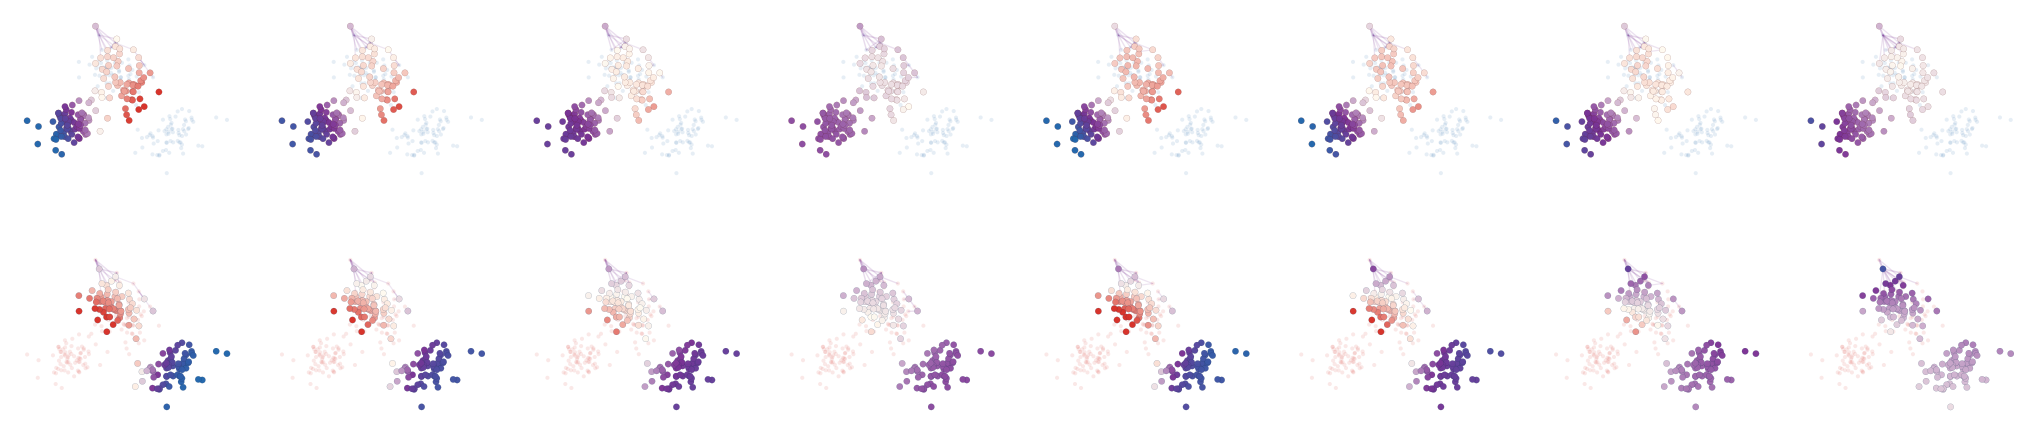

In [6]:
from IPython.display import Image, display
_display_path = THUMB if THUMB.exists() else Path("thumbnails") / f"{NAME}.png"
display(Image(filename=str(_display_path)))
